### Лабораторная работа 1. Детектор границ Канни

In [ ]:
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import numpy as np

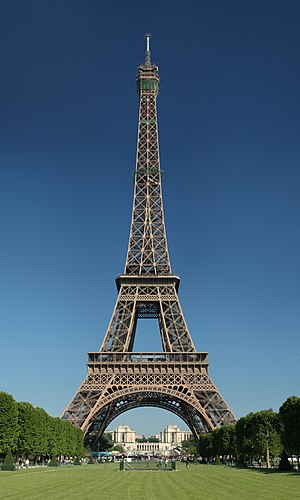

In [ ]:
image = cv2.imread('/content/drive/MyDrive/eifel.jpg')
cv2_imshow(image)

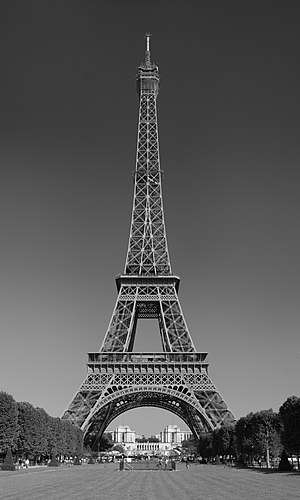

In [ ]:
# Оттенки серого
image = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
cv2_imshow(image)

In [ ]:
image

array([[ 53,  53,  53, ...,  49,  49,  49],
       [ 53,  53,  53, ...,  49,  49,  49],
       [ 53,  53,  53, ...,  49,  49,  49],
       ...,
       [131, 125, 127, ..., 113, 107, 112],
       [122, 118, 123, ..., 125, 121, 130],
       [129, 128, 130, ..., 120, 115, 121]], dtype=uint8)

In [ ]:
def convolution(input_image, kernel, kernel_size = 5):
  if kernel_size == 3:
    index = 1
  elif kernel_size == 5:
    index =2
  # padding
  # Вычисление количества строк и столбцов с нулями
  padding_rows = (kernel_size - 1) // 2  # количество строк и столбцов нулей, которые должны быть добавлены с каждой стороны изображения
  padding_cols = padding_rows

  # Вставка нулей вокруг изображения
  padded_image = np.pad(input_image, ((padding_rows, padding_rows), (padding_cols, padding_cols)), mode = 'constant')

  # print(padded_image)

  processed_image = np.zeros(padded_image.shape)
  for row in range(index, len(processed_image) - index):  # перебираем строки начиная со второй по счету (индекс 1)
    for column in range(index,len(processed_image[0]) - index): # перебираем столбцы начиная со второго по счету (индекс 1)
      processed_area = padded_image[row-index:row+index+1,column-index:column+index+1] # выделяем область исходного изображения для вычислений
      processed_image[row,column] = np.abs(np.sum(processed_area * kernel)) # свертка
  processed_image = processed_image[index:-index, index:-index]
  return processed_image

##### Удаляем шумы фильтром Гаусса

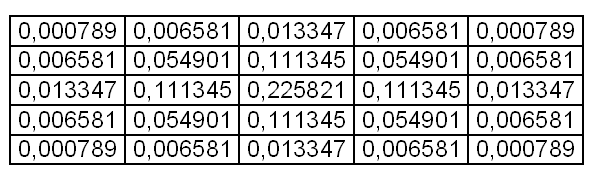

In [ ]:
gauss_kernel = np.array([[0.000789, 0.006581, 0.013347, 0.006581, 0.000789],
                         [0.006581, 0.054901, 0.111345, 0.054901, 0.006581],
                         [0.013347, 0.111345, 0.225821, 0.111345, 0.013347],
                         [0.006581, 0.054901, 0.111345, 0.054901,0.006581],
                         [0.000789, 0.006581, 0.013347,0.006581,0.000789]])

In [ ]:
gauss_image = convolution(image,gauss_kernel)
gauss_image.shape

(500, 300)

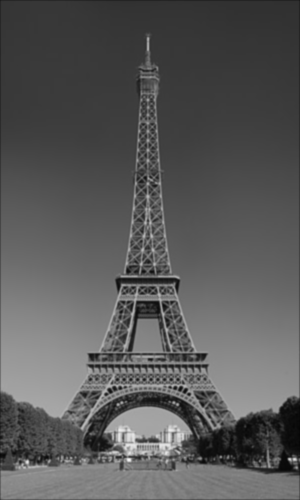

In [ ]:
cv2_imshow(gauss_image)

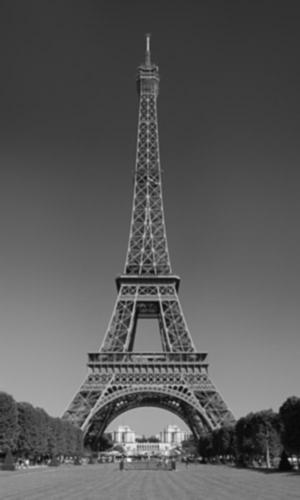

In [ ]:
gauss_image = cv2.filter2D(image, ddepth = -1,kernel = gauss_kernel)
cv2_imshow(gauss_image)

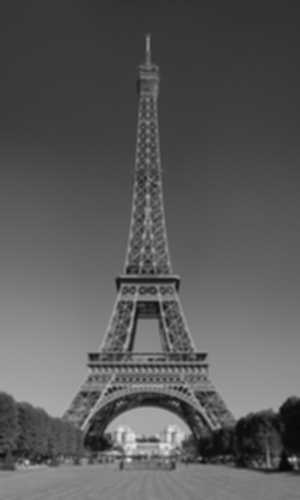

In [ ]:
# Убираем шум с помощью OpenCV
gauss_image_cv2 = cv2.GaussianBlur(image, (5, 5), 1.4)
cv2_imshow(gauss_image_cv2)

##### Применяем оператор Собеля для подсчета градиентов

In [ ]:
sobel_matrix_horizontal = np.array([
                          [1,0,1],
                          [-2,0,2],
                          [-1,0,1]
])
sobel_matrix_horizontal

array([[ 1,  0,  1],
       [-2,  0,  2],
       [-1,  0,  1]])

In [ ]:
sobel_matrix_vertical = np.array([
                          [-1,-2,-1],
                          [0,0,0],
                          [1,2,1]
])
sobel_matrix_vertical

array([[-1, -2, -1],
       [ 0,  0,  0],
       [ 1,  2,  1]])

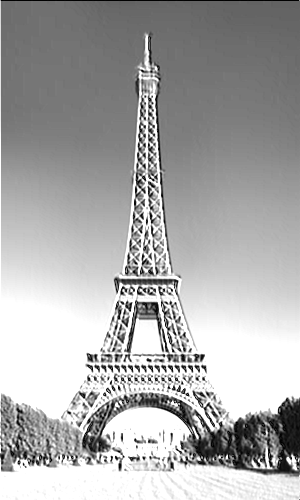

In [ ]:
sobel_horiz_image = convolution(gauss_image, sobel_matrix_horizontal, kernel_size = 3)
cv2_imshow(sobel_horiz_image)

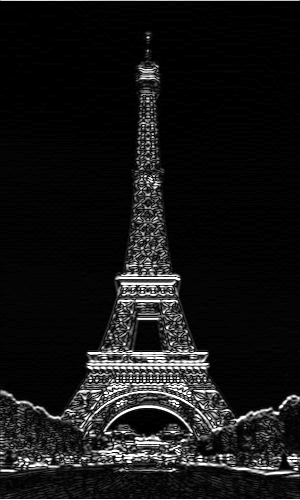

In [ ]:
sobel_vertical_image = convolution(gauss_image, sobel_matrix_vertical, kernel_size = 3)
cv2_imshow(sobel_vertical_image)

In [ ]:
magnitude, angle = cv2.cartToPolar(sobel_horiz_image, sobel_vertical_image, angleInDegrees=True)

In [ ]:
magnitude.shape

(500, 300)

In [ ]:
angle.shape

(500, 300)

In [ ]:
angle

array([[44.99045563, 90.        , 90.        , ..., 90.        ,
        90.        , 44.99045563],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 4.162889  ,  9.08153629,  4.69209385, ..., 14.63420963,
        12.55836391,  8.12947845],
       [ 1.92764795,  3.64246297,  0.4121055 , ...,  9.85422611,
        10.00779819,  6.95219088],
       [44.99045563, 62.79798508, 61.92717361, ..., 64.00817108,
        63.28847885, 71.07967377]])

##### Подавление не-максимумов и Двойное пороговое значение

In [ ]:
height, width = gauss_image.shape

In [ ]:
# setting the minimum and maximum thresholds
# for double thresholding
weak_th = None
strong_th = None

mag_max = np.max(magnitude)
if not weak_th:weak_th = mag_max * 0.1
if not strong_th:strong_th = mag_max * 0.5

In [ ]:
weak_th

72.22146495329488

In [ ]:
strong_th

361.1073247664744

In [ ]:
# Looping through every pixel of the grayscale
# image
for i_x in range(width):
  for i_y in range(height):

    grad_ang = angle[i_y, i_x]
    grad_ang = abs(grad_ang-180) if abs(grad_ang)>180 else abs(grad_ang)

    # selecting the neighbours of the target pixel
    # according to the gradient direction
    # In the x axis direction
    if grad_ang<= 22.5:

      neighb_1_x, neighb_1_y = i_x-1, i_y
      neighb_2_x, neighb_2_y = i_x + 1, i_y

    # top right (diagonal-1) direction
    elif grad_ang>22.5 and grad_ang<=(22.5 + 45):
      neighb_1_x, neighb_1_y = i_x-1, i_y-1
      neighb_2_x, neighb_2_y = i_x + 1, i_y + 1

    # In y-axis direction
    elif grad_ang>(22.5 + 45) and grad_ang<=(22.5 + 90):
      neighb_1_x, neighb_1_y = i_x, i_y-1
      neighb_2_x, neighb_2_y = i_x, i_y + 1

    # top left (diagonal-2) direction
    elif grad_ang>(22.5 + 90) and grad_ang<=(22.5 + 135):
      neighb_1_x, neighb_1_y = i_x-1, i_y + 1
      neighb_2_x, neighb_2_y = i_x + 1, i_y-1

    # Now it restarts the cycle
    elif grad_ang>(22.5 + 135) and grad_ang<=(22.5 + 180):
      neighb_1_x, neighb_1_y = i_x-1, i_y
      neighb_2_x, neighb_2_y = i_x + 1, i_y

    # Non-maximum suppression step
    if width>neighb_1_x>= 0 and height>neighb_1_y>= 0:
      if magnitude[i_y, i_x]<magnitude[neighb_1_y, neighb_1_x]:
        magnitude[i_y, i_x]= 0
        continue

    if width>neighb_2_x>= 0 and height>neighb_2_y>= 0:
      if magnitude[i_y, i_x]<magnitude[neighb_2_y, neighb_2_x]:
        magnitude[i_y, i_x]= 0

# weak_ids = np.zeros_like(gauss_image)
# strong_ids = np.zeros_like(gauss_image)
ids = np.zeros_like(gauss_image)

# double thresholding step
for i_x in range(width):
  for i_y in range(height):

    grad_mag = magnitude[i_y, i_x]

    if grad_mag<weak_th:
      magnitude[i_y, i_x]= 0

    elif strong_th>grad_mag>= weak_th:
      ids[i_y, i_x]= 0
    else:
      ids[i_y, i_x]= 255

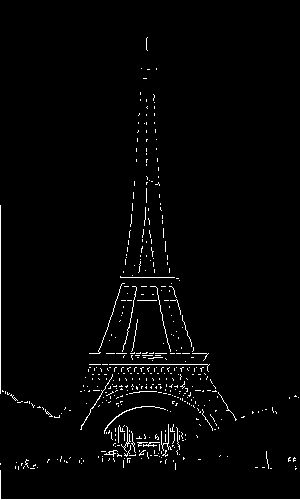

In [ ]:
cv2_imshow(ids)

##### Отслеживание краев с использованием гистерезиса

In [ ]:
# Создадим массивы для слабых и сильных пикселей границ
weak_ids = np.zeros_like(gauss_image)
strong_ids = np.zeros_like(gauss_image)


# Для каждого пикселя в изображении
for i_x in range(width):
  for i_y in range(height):
    # Если текущий пиксель является сильным пикселем границы
    if ids[i_y, i_x] == 255:
      # Пометить пиксель как сильный
      strong_ids[i_y, i_x] = 255
      # Проверить соседние пиксели восьми направлениях
      for dx in range(-1, 2):
        for dy in range(-1, 2):
          nx, ny = i_x + dx, i_y + dy
          # Проверить границы изображения
          if nx >= 0 and ny >= 0 and nx < width and ny < height:
            # Если соседний пиксель является слабым пикселем границы
            if weak_th <= magnitude[ny, nx] < strong_th:
              # Пометить пиксель как слабый
              weak_ids[ny, nx] = 255

# Объединить слабые пиксели границы с сильными пикселями границы
edge_image = strong_ids + weak_ids

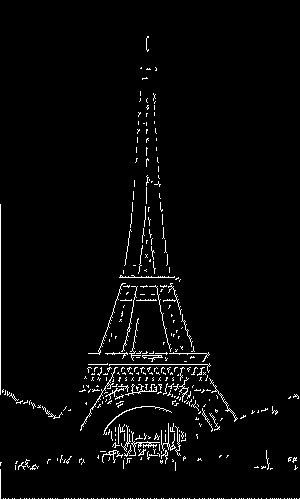

In [ ]:
cv2_imshow(edge_image)

##### Canny detector

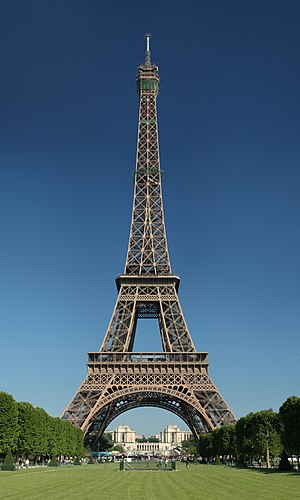

In [ ]:
image = cv2.imread('/content/drive/MyDrive/eifel.jpg')
cv2_imshow(image)

In [ ]:
def canny(image):
  # Оттенки серого
  gray_image = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

  # Удаляем шумы фильтром Гаусса
  gauss_image = convolution(gray_image,gauss_kernel)

  # Применяем оператор Собеля для подсчета градиентов
  sobel_horiz_image = convolution(gauss_image, sobel_matrix_horizontal, kernel_size = 3)
  sobel_vertical_image = convolution(gauss_image, sobel_matrix_vertical, kernel_size = 3)

  # Переходим в полярную систему координат, вычисляем матрицу амплитуд и углов наклона векторов градиентов
  magnitude, angle = cv2.cartToPolar(sobel_horiz_image, sobel_vertical_image, angleInDegrees=True)

  # Подавление не-максимумов и Двойное пороговое значение
  for i_x in range(width):
    for i_y in range(height):
      grad_ang = angle[i_y, i_x]
      grad_ang = abs(grad_ang-180) if abs(grad_ang)>180 else abs(grad_ang)

      # selecting the neighbours of the target pixel
      # according to the gradient direction
      # In the x axis direction
      if grad_ang<= 22.5:

        neighb_1_x, neighb_1_y = i_x-1, i_y
        neighb_2_x, neighb_2_y = i_x + 1, i_y

      # top right (diagonal-1) direction
      elif grad_ang>22.5 and grad_ang<=(22.5 + 45):
        neighb_1_x, neighb_1_y = i_x-1, i_y-1
        neighb_2_x, neighb_2_y = i_x + 1, i_y + 1

      # In y-axis direction
      elif grad_ang>(22.5 + 45) and grad_ang<=(22.5 + 90):
        neighb_1_x, neighb_1_y = i_x, i_y-1
        neighb_2_x, neighb_2_y = i_x, i_y + 1

      # top left (diagonal-2) direction
      elif grad_ang>(22.5 + 90) and grad_ang<=(22.5 + 135):
        neighb_1_x, neighb_1_y = i_x-1, i_y + 1
        neighb_2_x, neighb_2_y = i_x + 1, i_y-1

      # Now it restarts the cycle
      elif grad_ang>(22.5 + 135) and grad_ang<=(22.5 + 180):
        neighb_1_x, neighb_1_y = i_x-1, i_y
        neighb_2_x, neighb_2_y = i_x + 1, i_y

      # Non-maximum suppression step
      if width>neighb_1_x>= 0 and height>neighb_1_y>= 0:
        if magnitude[i_y, i_x]<magnitude[neighb_1_y, neighb_1_x]:
          magnitude[i_y, i_x]= 0
          continue

      if width>neighb_2_x>= 0 and height>neighb_2_y>= 0:
        if magnitude[i_y, i_x]<magnitude[neighb_2_y, neighb_2_x]:
          magnitude[i_y, i_x]= 0

  # weak_ids = np.zeros_like(gauss_image)
  # strong_ids = np.zeros_like(gauss_image)
  ids = np.zeros_like(gauss_image)

  # double thresholding step
  for i_x in range(width):
    for i_y in range(height):

      grad_mag = magnitude[i_y, i_x]

      if grad_mag<weak_th:
        magnitude[i_y, i_x]= 0

      elif strong_th>grad_mag>= weak_th:
        ids[i_y, i_x]= 0
      else:
        ids[i_y, i_x]= 255

  # Отслеживание краев с использованием гистерезиса
  # Создадим массивы для слабых и сильных пикселей границ
  weak_ids = np.zeros_like(gauss_image)
  strong_ids = np.zeros_like(gauss_image)


  # Для каждого пикселя в изображении
  for i_x in range(width):
    for i_y in range(height):
      # Если текущий пиксель является сильным пикселем границы
      if ids[i_y, i_x] == 255:
        # Пометить пиксель как сильный
        strong_ids[i_y, i_x] = 255
        # Проверить соседние пиксели восьми направлениях
        for dx in range(-1, 2):
          for dy in range(-1, 2):
            nx, ny = i_x + dx, i_y + dy
            # Проверить границы изображения
            if nx >= 0 and ny >= 0 and nx < width and ny < height:
              # Если соседний пиксель является слабым пикселем границы
              if weak_th <= magnitude[ny, nx] < strong_th:
                # Пометить пиксель как слабый
                weak_ids[ny, nx] = 255

  # Объединить слабые пиксели границы с сильными пикселями границы
  edge_image = strong_ids + weak_ids
  return edge_image

In [ ]:
edge_image = canny(image)

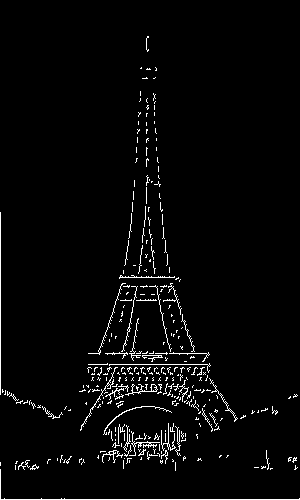

In [ ]:
cv2_imshow(edge_image)